# Visualization and perturbation-effect exploration

This notebook uses the QC-complete Norman Perturb-seq subset generated by `02_quality_control.ipynb`. It asks three descriptive questions:

1. Where do the selected perturbations appear in the existing low-dimensional representation?
2. Does each CRISPRa perturbation increase expression of its intended target gene?
3. Which transcriptome-wide expression shifts are most characteristic of each perturbation?

The analyses are exploratory. Individual cells from the same experiment are not independent biological replicates, so cell-level differences are not treated as replicate-level statistical evidence.

In [1]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/home/tuobawen/miniconda3/envs/mini-perturbseq/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## Load and validate the QC-complete dataset

The path logic supports launching Jupyter from either the repository root or the `notebooks/` directory. If the cached file is missing, run notebook 02 through its final save cell.

In [2]:
current_directory = Path.cwd().resolve()
project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)
qc_path = project_root / "data" / "norman_2019_qc.h5ad"

if not qc_path.exists():
    raise FileNotFoundError(
        f"QC dataset not found at {qc_path}. "
        "Run notebooks/02_quality_control.ipynb first."
    )

adata_qc = sc.read_h5ad(qc_path)
selected_perturbations = ["KLF1", "BAK1", "CEBPE", "ETS2", "MAP2K6"]
plot_order = ["control"] + selected_perturbations

assert adata_qc.obs["number_of_cells"].eq(1).all()
assert adata_qc.obs["good_coverage"].astype(bool).all()
assert "counts" in adata_qc.layers
assert {"X_pca", "X_umap"}.issubset(adata_qc.obsm.keys())

print(adata_qc)
adata_qc.obs["perturbation_name"].value_counts().reindex(plot_order)

AnnData object with n_obs × n_vars = 15209 × 19018
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804', 'guide_KIF18B', 'guide_KIF2C', 'g

perturbation_name
control    9687
KLF1       1625
BAK1       1149
CEBPE      1008
ETS2       1010
MAP2K6      730
Name: count, dtype: int64

## Existing embedding as descriptive context

The downloaded object already contains PCA, neighbor-graph, Leiden, and UMAP results computed during source-dataset preprocessing. Subsetting preserves each retained cell's coordinates. These coordinates provide useful context, but they were not recomputed exclusively from our six-group cohort and should not be interpreted as a quantitative perturbation-effect test.

UMAP emphasizes local neighborhoods and can distort global distances. Separation—or overlap—on UMAP is therefore suggestive, not proof that a perturbation does or does not have an expression effect.

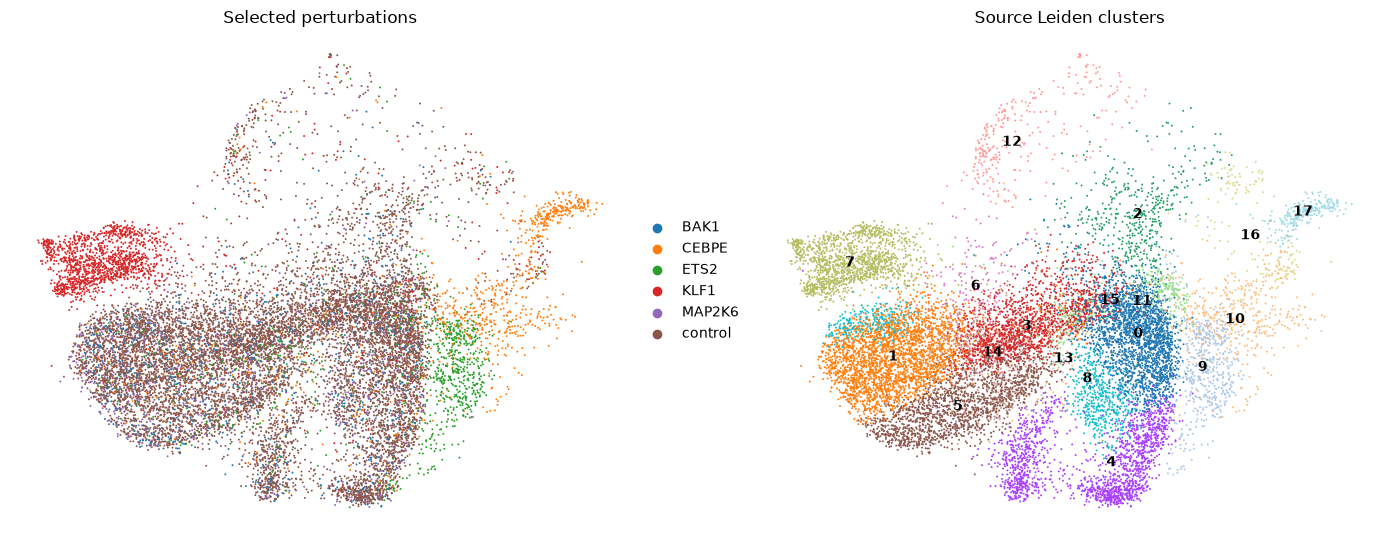

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sc.pl.umap(
    adata_qc,
    color="perturbation_name",
    groups=plot_order,
    ax=axes[0],
    show=False,
    frameon=False,
    title="Selected perturbations",
)
sc.pl.umap(
    adata_qc,
    color="leiden",
    ax=axes[1],
    show=False,
    frameon=False,
    legend_loc="on data",
    title="Source Leiden clusters",
)

plt.tight_layout()
plt.show()

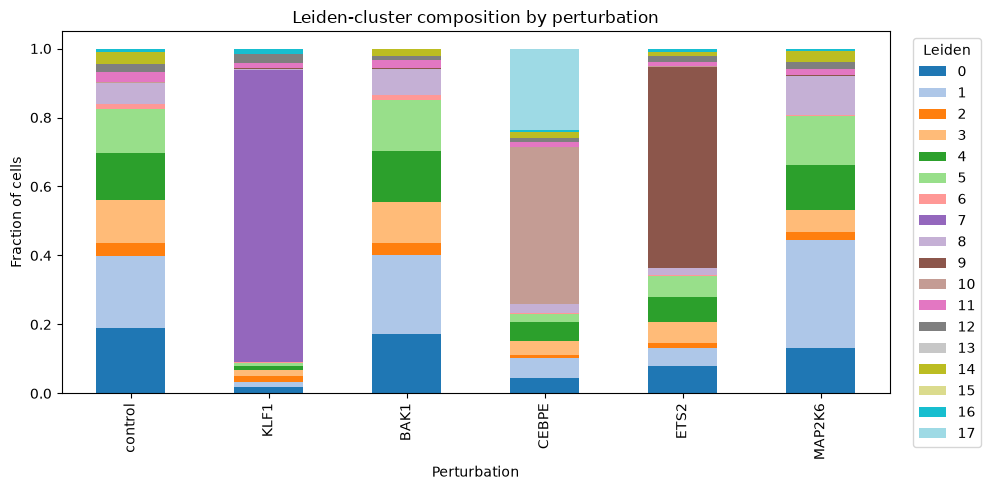

In [4]:
cell_composition = pd.crosstab(
    adata_qc.obs["leiden"],
    adata_qc.obs["perturbation_name"],
    normalize="columns",
).reindex(columns=plot_order)

ax = cell_composition.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    colormap="tab20",
)
ax.set_xlabel("Perturbation")
ax.set_ylabel("Fraction of cells")
ax.set_title("Leiden-cluster composition by perturbation")
ax.legend(title="Leiden", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## On-target expression response

Norman et al. used CRISPR activation (CRISPRa), so a basic positive-control question is whether cells assigned to each perturbation show increased normalized expression of the intended target. For each target, we compare its matching perturbation with negative-control cells.

`.X` contains non-negative, log-transformed normalized expression, while `.layers["counts"]` retains integer count-scale values. The summaries below use `.X` for visualization. They report means, medians, and detection fractions rather than formal p-values.

In [5]:
target_rows = []

for gene in selected_perturbations:
    if gene not in adata_qc.var_names:
        raise KeyError(f"Target gene {gene} is absent from the expression matrix")

    gene_expression = np.asarray(adata_qc[:, gene].X.toarray()).ravel()
    for group in ["control", gene]:
        group_mask = adata_qc.obs["perturbation_name"].eq(group).to_numpy()
        values = gene_expression[group_mask]
        target_rows.append(
            {
                "target_gene": gene,
                "group": group,
                "n_cells": values.size,
                "mean_log_expression": values.mean(),
                "median_log_expression": np.median(values),
                "detected_fraction": np.mean(values > 0),
            }
        )

target_expression_summary = pd.DataFrame(target_rows)
target_expression_summary

,target_gene,group,n_cells,mean_log_expression,median_log_expression,detected_fraction
0,KLF1,control,9687,0.404827,0.433580,0.582224
1,KLF1,KLF1,1625,1.221979,1.283749,0.928615
2,BAK1,control,9687,0.144983,0.000000,0.259007
3,BAK1,BAK1,1149,0.674024,0.711894,0.776327
4,CEBPE,control,9687,0.013733,0.000000,0.026221
5,CEBPE,CEBPE,1008,1.591565,1.712301,0.890873
6,ETS2,control,9687,0.060737,0.000000,0.116032
7,ETS2,ETS2,1010,0.434574,0.462232,0.556436
8,MAP2K6,control,9687,0.000103,0.000000,0.000206
9,MAP2K6,MAP2K6,730,0.053742,0.000000,0.110959


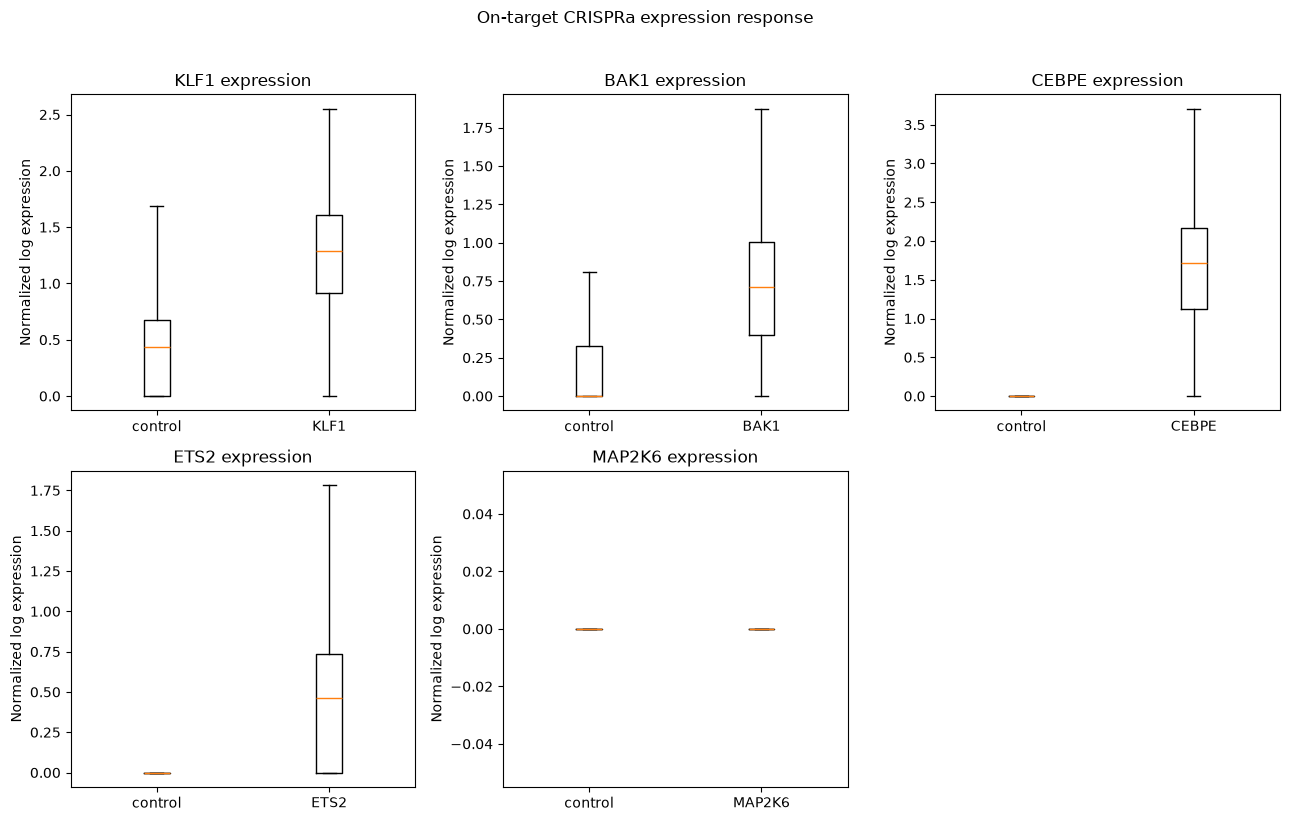

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

for ax, gene in zip(axes, selected_perturbations):
    gene_expression = np.asarray(adata_qc[:, gene].X.toarray()).ravel()
    values = [
        gene_expression[
            adata_qc.obs["perturbation_name"].eq(group).to_numpy()
        ]
        for group in ["control", gene]
    ]
    ax.boxplot(values, showfliers=False)
    ax.set_xticks([1, 2], ["control", gene])
    ax.set_title(f"{gene} expression")
    ax.set_ylabel("Normalized log expression")

axes[-1].axis("off")
fig.suptitle("On-target CRISPRa expression response", y=1.02)
plt.tight_layout()
plt.show()

## Transcriptome-wide descriptive effect vectors

For each perturbation, we calculate the difference between its mean normalized expression and the control mean across the 5,000 source-defined highly variable genes (HVGs). This creates a descriptive effect vector:

`mean expression in perturbation cells − mean expression in control cells`

Positive values indicate higher average normalized expression than controls; negative values indicate lower expression. Because all cells come from the same experimental context, these vectors summarize observed shifts but do not provide replicate-level uncertainty.

In [7]:
hvg_mask = adata_qc.var["highly_variable"].astype(bool).to_numpy()
hvg_names = adata_qc.var_names[hvg_mask]
hvg_expression = adata_qc[:, hvg_mask].X

control_mask = adata_qc.obs["perturbation_name"].eq("control").to_numpy()
control_mean = np.asarray(hvg_expression[control_mask].mean(axis=0)).ravel()

effect_vectors = {}
for perturbation in selected_perturbations:
    perturbation_mask = adata_qc.obs["perturbation_name"].eq(perturbation).to_numpy()
    perturbation_mean = np.asarray(
        hvg_expression[perturbation_mask].mean(axis=0)
    ).ravel()
    effect_vectors[perturbation] = perturbation_mean - control_mean

effect_df = pd.DataFrame(effect_vectors, index=hvg_names)
effect_df.head()

,KLF1,BAK1,CEBPE,ETS2,MAP2K6
gene_symbols,,,,,
RP11-34P13.7,-0.000194,-0.001284,0.003202,-0.000247,-0.001284
FO538757.2,-0.016449,-0.010250,0.008074,0.032243,-0.033766
RP11-54O7.3,-0.000105,-0.000558,0.014805,-0.002087,-0.001341
SAMD11,-0.000836,0.001240,0.020480,-0.003035,-0.000454
HES4,0.021913,-0.002272,-0.055248,0.006508,0.015433


In [8]:
top_effect_rows = []

for perturbation in selected_perturbations:
    effects = effect_df[perturbation]
    for direction, genes in {
        "higher": effects.nlargest(10),
        "lower": effects.nsmallest(10),
    }.items():
        for rank, (gene, effect) in enumerate(genes.items(), start=1):
            top_effect_rows.append(
                {
                    "perturbation": perturbation,
                    "direction": direction,
                    "rank": rank,
                    "gene": gene,
                    "mean_log_expression_difference": effect,
                }
            )

top_effect_genes = pd.DataFrame(top_effect_rows)
top_effect_genes

,perturbation,direction,rank,gene,mean_log_expression_difference
0,KLF1,higher,1,HBZ,1.558454
1,KLF1,higher,2,HBG2,1.265368
2,KLF1,higher,3,TMSB10,1.196118
3,KLF1,higher,4,HBG1,0.817542
4,KLF1,higher,5,KLF1,0.817151
...,...,...,...,...,...
95,MAP2K6,lower,6,PPP1R14A,-0.154285
96,MAP2K6,lower,7,COL18A1,-0.142306
97,MAP2K6,lower,8,NME4,-0.141853
98,MAP2K6,lower,9,GYPC,-0.141043


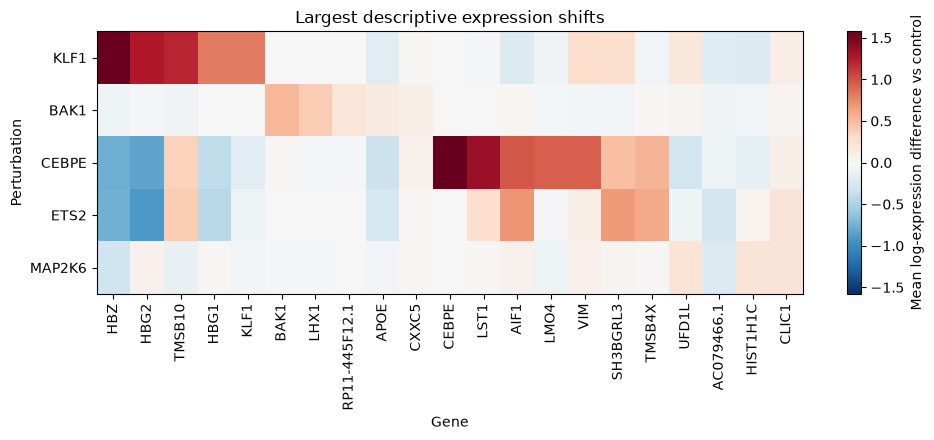

In [9]:
top_genes = []
for perturbation in selected_perturbations:
    top_genes.extend(
        effect_df[perturbation].abs().nlargest(5).index.tolist()
    )
top_genes = list(dict.fromkeys(top_genes))

heatmap_data = effect_df.loc[top_genes, selected_perturbations].T
color_limit = np.abs(heatmap_data.to_numpy()).max()

fig, ax = plt.subplots(figsize=(max(10, len(top_genes) * 0.45), 4.5))
image = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-color_limit,
    vmax=color_limit,
)
ax.set_xticks(range(len(top_genes)), top_genes, rotation=90)
ax.set_yticks(range(len(selected_perturbations)), selected_perturbations)
ax.set_xlabel("Gene")
ax.set_ylabel("Perturbation")
ax.set_title("Largest descriptive expression shifts")
fig.colorbar(image, ax=ax, label="Mean log-expression difference vs control")
plt.tight_layout()
plt.show()

## Similarity and magnitude of perturbation effects

Correlating effect vectors asks whether two perturbations shift the same HVGs in similar directions. The Euclidean norm summarizes the overall magnitude of each mean-shift vector. Both measures are descriptive and depend on the selected gene space and normalization.

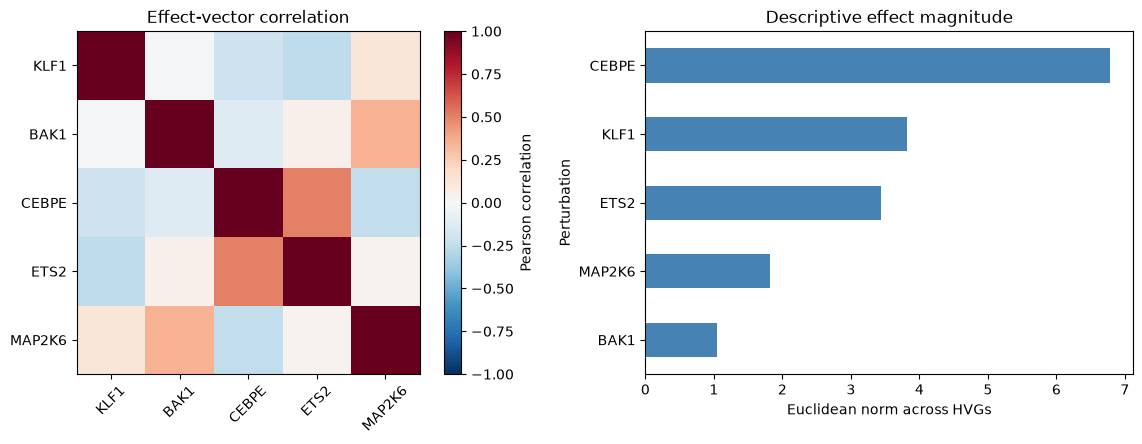

,KLF1,BAK1,CEBPE,ETS2,MAP2K6
KLF1,1.000000,-0.013793,-0.209045,-0.251746,0.125000
BAK1,-0.013793,1.000000,-0.129635,0.047155,0.348088
CEBPE,-0.209045,-0.129635,1.000000,0.500947,-0.247006
ETS2,-0.251746,0.047155,0.500947,1.000000,0.033842
MAP2K6,0.125000,0.348088,-0.247006,0.033842,1.000000


In [10]:
effect_correlation = effect_df.corr(method="pearson")
effect_magnitude = np.sqrt(effect_df.pow(2).sum(axis=0)).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

correlation_image = axes[0].imshow(
    effect_correlation,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)
axes[0].set_xticks(
    range(len(selected_perturbations)), selected_perturbations, rotation=45
)
axes[0].set_yticks(range(len(selected_perturbations)), selected_perturbations)
axes[0].set_title("Effect-vector correlation")
fig.colorbar(correlation_image, ax=axes[0], label="Pearson correlation")

effect_magnitude.plot.barh(ax=axes[1], color="steelblue")
axes[1].set_xlabel("Euclidean norm across HVGs")
axes[1].set_ylabel("Perturbation")
axes[1].set_title("Descriptive effect magnitude")

plt.tight_layout()
plt.show()

effect_correlation

## Interpretation of the exploratory results

A validated execution of this notebook supports four main observations:

1. **Embedding and cluster composition:** KLF1 occupies a particularly distinct UMAP region and is concentrated in one source Leiden cluster. CEBPE and ETS2 also strongly alter cluster composition, while BAK1 and MAP2K6 overlap controls more extensively. These patterns indicate state redistribution, not formal effect sizes.
2. **On-target response:** Every intended target has higher mean expression and detection in its matching CRISPRa group than in controls. KLF1, BAK1, CEBPE, and ETS2 show clear shifts. MAP2K6 increases from 0.02% detection in controls to 11.1% in MAP2K6 cells, but most MAP2K6 cells still have zero measured expression, making its on-target response weaker or more sparsely detected.
3. **Characteristic expression programs:** KLF1 produces an erythroid-like program dominated by HBZ, HBG2, HBG1, and KLF1 itself. CEBPE produces the largest overall HVG mean-shift vector and prominently increases CEBPE, LST1, AIF1, LMO4, and VIM. BAK1 has the smallest overall mean-shift magnitude among the five selected perturbations.
4. **Effect similarity:** CEBPE and ETS2 have the strongest effect-vector correlation (`r ≈ 0.50`), suggesting partially shared expression responses. BAK1 and MAP2K6 show a weaker positive relationship (`r ≈ 0.35`). Other pairs are weakly correlated or anticorrelated.

These findings justify moving to a focused differential-expression and pathway-interpretation stage, but the inferential scope must remain explicit. Formal condition-level claims require independent biological replicates; thousands of cells from one experimental context do not create thousands of independent replicates. The next analysis should therefore distinguish descriptive cell-level rankings from replicate-aware inference and include a sensitivity comparison against the broader, unfiltered cohort.